# Project Title
- Customer Retention and Churn Analysis for a Subscription Business

# Business Problem
- Customer churn is a major challenge in subscription-based business. This project analyzes customer behavior to identify churn patterns and recommend strategies to improve retention.

# Objectives
- Identify key churn drivers
- Perform cohort analysis
- Analyze customer lifetime value
- Provide actionable business recommendations

# Tools Used
- Python (pandas, numpy, matplotlib, seaborn)

# Dataset
- Telcom Customer Churn Dataset
- Source: kaggle (https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [2]:
raw_telco_dataset = pd.read_csv("../Data/Telco_Customer_Churn.csv")
raw_telco_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Understand the dataset
- The dataset contains 7043 rows that represent customers and 21 columns of attributes
- The total number of customers who stop using Telcom service is 1869 and the number of those who did not stop using telcom service is 5174.

In [3]:
raw_telco_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
raw_telco_dataset.describe(include = 'all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [5]:
raw_telco_dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
raw_telco_dataset['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Data cleaning

In [7]:
# Converting Total charrges to Numeric
raw_telco_dataset['TotalCharges'] = pd.to_numeric(raw_telco_dataset['TotalCharges'], errors = 'coerce')

In [8]:
# Handling the missing values
raw_telco_dataset.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
Nonull_dataset = raw_telco_dataset.dropna().copy()

In [10]:
Nonull_dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
Nonull_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Feature Engineering

In [12]:
# Create tenure groups
def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 Year"
    elif tenure <= 24:
        return "1-2 Years"
    elif tenure <= 48:
        return "2-4 Years"
    else:
        return "4+ Years"

Nonull_dataset['tenure_group'] = Nonull_dataset['tenure'].apply(tenure_group)

In [13]:
Nonull_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year


## Creating Churn Rate

In [14]:
Churn_rate = Nonull_dataset['Churn'].value_counts(normalize = True) * 100
print(Churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


## Exploratory Data Analysis

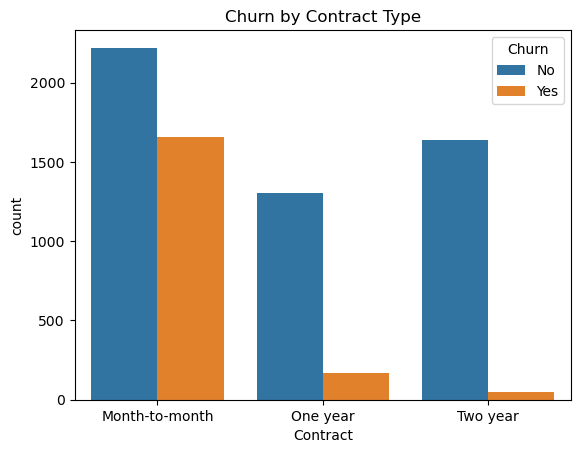

In [15]:
# Churn by Contract Type
sns.countplot(x = 'Contract', hue = 'Churn', data = Nonull_dataset)
plt.title ("Churn by Contract Type")
plt.show()

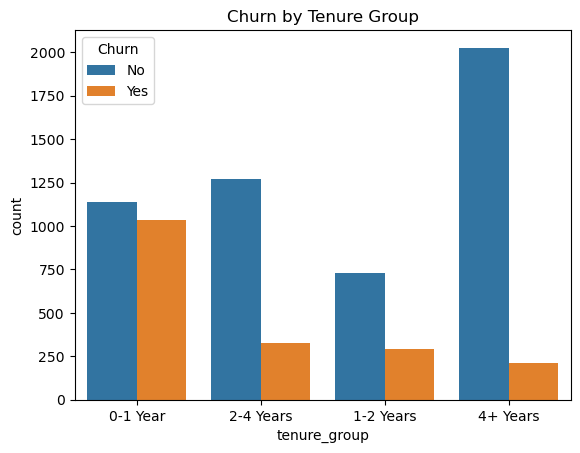

In [16]:
# Churn by Tenure
sns.countplot(x = 'tenure_group', hue = 'Churn', data = Nonull_dataset)
plt.title ("Churn by Tenure Group")
plt.show()


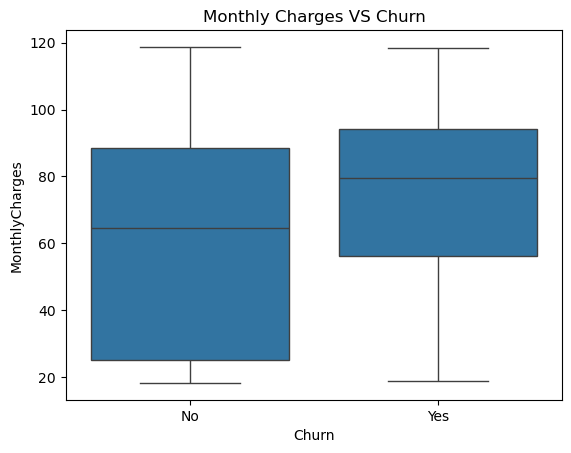

In [17]:
# Monthly Charges VS Churn
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = Nonull_dataset)
plt.title ("Monthly Charges VS Churn")
plt.show()

## Cohort Analysis

In [18]:
cohort = Nonull_dataset.groupby('tenure_group')['Churn'].value_counts(normalize = True).unstack()
print(cohort)

Churn               No       Yes
tenure_group                    
0-1 Year      0.523218  0.476782
1-2 Years     0.712891  0.287109
2-4 Years     0.796110  0.203890
4+ Years      0.904868  0.095132


## Customer Lifetime Value(CLV)

In [19]:
Nonull_dataset['CLV'] = Nonull_dataset['MonthlyCharges'] * Nonull_dataset['tenure']
Nonull_dataset[['CLV', 'Churn']].groupby('Churn').mean()

,CLV
Churn,
No,2555.203283
Yes,1531.608828


# Key Insights
- Analysis showed that Customers on month-to-month contracts have the highest churn rate
- Customers in the 0-1 year tenure group churn the most
- Customers with higher monthly charges are more likely to churn
- Analysis shows that long-term customers generate significantly higher revenue (CLV)

This analysis demostrates that customer churn is driven by contract type, tenure, and pricing factors.

In [20]:
# Saving cleaned dataset
Nonull_dataset.to_csv('Cleaned_dataset.csv', index = False)
